# ASL Alphabet Recognition — ML Model
Trains a **MobileNetV2** transfer-learning model on the Kaggle ASL Alphabet dataset,
then runs real-time inference on a live webcam feed using MediaPipe for hand detection.

**Pipeline:**
1. Download dataset from Kaggle
2. Preprocess images & build data generators
3. Train MobileNetV2 (frozen base → fine-tune)
4. Save model + class labels
5. Live webcam inference


## 0 · Install / import dependencies

In [11]:
# Install kaggle package if not already present
import importlib, subprocess, sys
from dotenv import load_dotenv
load_dotenv()    

if importlib.util.find_spec('kaggle') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kaggle', '-q'])

print('All packages ready.')


All packages ready.


In [10]:
!pip show python-dotenv   

Name: python-dotenv
Version: 1.2.2
Summary: Read key-value pairs from a .env file and set them as environment variables
Home-page: 
Author: 
Author-email: Saurabh Kumar <me+github@saurabh-kumar.com>
License: BSD-3-Clause
Location: /Users/chrisdollo/Documents/Research/putEMG prime/venv/lib/python3.13/site-packages
Requires: 
Required-by: 


## 1 · Kaggle credentials
Create a free account at [kaggle.com](https://www.kaggle.com), then go to  
**Account → API → Create New Token** — this downloads `kaggle.json`.  

Paste your `username` and `key` below **or** copy `kaggle.json` to `~/.kaggle/kaggle.json` and skip this cell.


In [12]:
import os, json

KAGGLE_USERNAME = 'chrisdollo'   # e.g. 'johndoe'
KAGGLE_KEY      = os.environ.get('KAGGLE_KEY')   # the hex key from kaggle.json

if KAGGLE_USERNAME and KAGGLE_KEY:
    kaggle_dir = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)
    cred_path = os.path.join(kaggle_dir, 'kaggle.json')
    with open(cred_path, 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod(cred_path, 0o600)
    print('Credentials saved to', cred_path)
else:
    print('Skipping — using existing ~/.kaggle/kaggle.json')


Credentials saved to /Users/chrisdollo/.kaggle/kaggle.json


## 2 · Download ASL Alphabet dataset

In [15]:
import kaggle, os

DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# 87,000 images  |  29 classes (A-Z + del + nothing + space)  |  200x200 px
kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    'grassknoted/asl-alphabet',
    path=DATA_ROOT,
    unzip=True,
    quiet=False,
)

TRAIN_DIR = os.path.join(DATA_ROOT, 'asl_alphabet_train', 'asl_alphabet_train')
print('Training data at:', TRAIN_DIR)
print('Classes found:', sorted(os.listdir(TRAIN_DIR)))


Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet


100%|██████████| 1.03G/1.03G [02:08<00:00, 8.59MB/s]



Training data at: ./data/asl_alphabet_train/asl_alphabet_train
Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [23]:
pip install numpy opencv-python mediapipe tensorflow matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 7.8 MB/s  0:00:28m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 9.6 MB/s  0:00:01m0:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 8.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 9.7 MB/s  0:00:02m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [tensorflow]8 [tensorflow]-py]
Note: you may need to restart the kernel to use updated packages.


## 3 · Imports & configuration

In [24]:
import os, json
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)

# ── Config ──────────────────────────────────────────────────────────────
IMG_SIZE     = 96      # MobileNetV2 works well at 96x96, fast enough for real-time
BATCH_SIZE   = 64
EPOCHS_1     = 12      # phase 1 — frozen base
EPOCHS_2     = 6       # phase 2 — fine-tune top layers

TRAIN_DIR    = './data/asl_alphabet_train/asl_alphabet_train'
MODEL_PATH   = './asl_model.keras'
CLASSES_PATH = './asl_classes.json'


TensorFlow: 2.21.0


## 4 · Data generators

In [25]:
# Hold out 15 % of training images as validation set
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # MobileNetV2 expects [-1, 1]
    validation_split=0.15,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.75, 1.25],
    horizontal_flip=False,   # ASL letters are NOT left-right symmetric
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]

print(f'{NUM_CLASSES} classes: {CLASS_NAMES}')
print(f'Train batches: {len(train_gen)}   Val batches: {len(val_gen)}')


Found 73950 images belonging to 29 classes.
Found 13050 images belonging to 29 classes.
29 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Train batches: 1156   Val batches: 204


## 5 · Build model

In [26]:
# MobileNetV2 pretrained on ImageNet — classifier head removed
base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base.trainable = False   # freeze all base layers for phase 1

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,928,733 (11.17 MB)

 Trainable params: 670,749 (2.56 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6 · Phase 1 — train classifier head (base frozen)

In [27]:
callbacks_1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1),
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_1,
    callbacks=callbacks_1,
)


Epoch 1/12
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 385s 331ms/step - accuracy: 0.8455 - loss: 0.4889 - val_accuracy: 0.7831 - val_loss: 0.7239 - learning_rate: 0.0010
Epoch 2/12
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 486s 420ms/step - accuracy: 0.9248 - loss: 0.2191 - val_accuracy: 0.7923 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 3/12
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9367 - loss: 0.1860
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 468s 405ms/step - accuracy: 0.9379 - loss: 0.1813 - val_accuracy: 0.7873 - val_loss: 0.7810 - learning_rate: 0.0010
Epoch 4/12
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 452s 390ms/step - accuracy: 0.9578 - loss: 0.1229 - val_accuracy: 0.8000 - val_loss: 0.7718 - learning_rate: 5.0000e-04
Epoch 5/12
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9643 - loss: 0.1030
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 698s 604ms/s

## 7 · Phase 2 — fine-tune top layers of base

In [28]:
# Unfreeze the last 30 layers of MobileNetV2 and retrain at a low LR
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_2,
    callbacks=callbacks_2,
)


Epoch 1/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 698s 598ms/step - accuracy: 0.8823 - loss: 0.4293 - val_accuracy: 0.8138 - val_loss: 0.8659
Epoch 2/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 760s 658ms/step - accuracy: 0.9462 - loss: 0.1710 - val_accuracy: 0.8225 - val_loss: 0.7855
Epoch 3/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 841s 728ms/step - accuracy: 0.9612 - loss: 0.1183 - val_accuracy: 0.8287 - val_loss: 0.7446
Epoch 4/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 803s 695ms/step - accuracy: 0.9697 - loss: 0.0925 - val_accuracy: 0.8317 - val_loss: 0.7468
Epoch 5/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 559s 484ms/step - accuracy: 0.9758 - loss: 0.0724 - val_accuracy: 0.8312 - val_loss: 0.7736
Epoch 6/6
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 509s 440ms/step - accuracy: 0.9786 - loss: 0.0639 - val_accuracy: 0.8363 - val_loss: 0.7548
Restoring model weights from the end of the best epoch: 6.


## 8 · Training curves

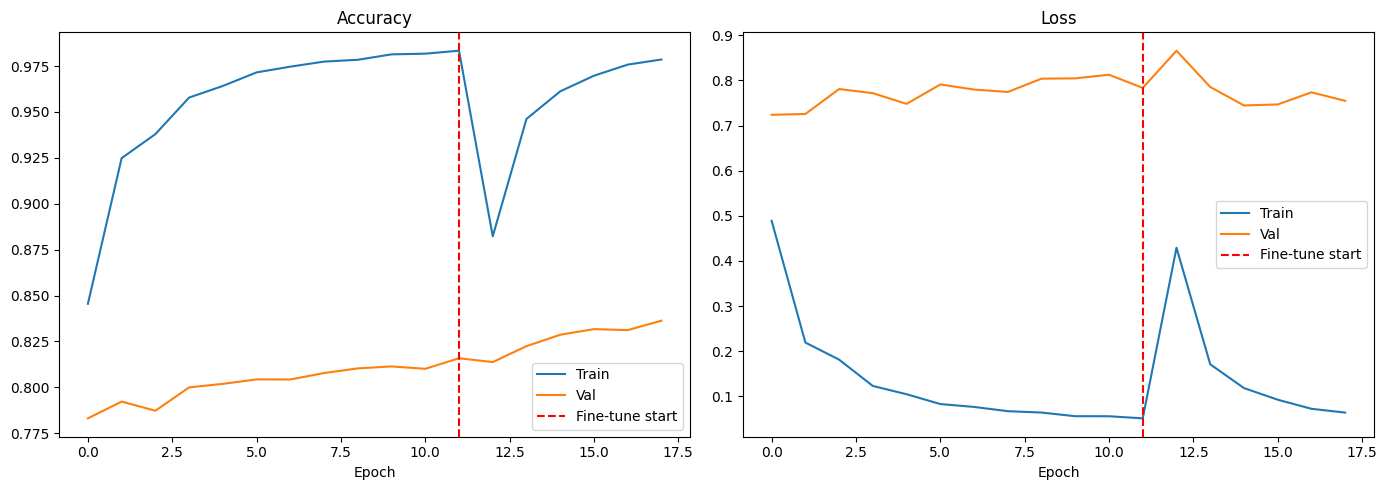

Final val accuracy: 83.6 %


In [29]:
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
split    = len(history1.history['accuracy'])  # epoch where fine-tuning starts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_vals, val_vals, title in [
    (axes[0], acc,  val_acc,  'Accuracy'),
    (axes[1], loss, val_loss, 'Loss'),
]:
    ax.plot(train_vals, label='Train')
    ax.plot(val_vals,   label='Val')
    ax.axvline(split - 1, color='red', linestyle='--', label='Fine-tune start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print(f'Final val accuracy: {val_acc[-1]*100:.1f} %')


## 9 · Save model & class labels

In [30]:
model.save(MODEL_PATH)
with open(CLASSES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f)

print(f'Model  -> {MODEL_PATH}')
print(f'Labels -> {CLASSES_PATH}')


Model  -> ./asl_model.keras
Labels -> ./asl_classes.json


## 10 · Live webcam inference
Loads the trained model and runs real-time ASL letter recognition on the webcam.

- **MediaPipe** detects the hand and draws the skeleton.
- The hand region is cropped using the landmark bounding box, resized to 96x96,
  and fed to the model.
- The predicted letter and confidence are shown on screen.
- Press **Q** to quit.


In [ ]:
import json, os, urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ── Load model & labels ─────────────────────────────────────────────────
MODEL_PATH   = './asl_model.keras'
CLASSES_PATH = './asl_classes.json'
IMG_SIZE     = 96

model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASSES_PATH) as f:
    CLASS_NAMES = json.load(f)

print('Model loaded. Classes:', CLASS_NAMES)

# ── Download MediaPipe hand landmark model ───────────────────────────────
HAND_MODEL_PATH = './hand_landmarker.task'
if not os.path.exists(HAND_MODEL_PATH):
    print('Downloading hand landmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task',
        HAND_MODEL_PATH,
    )
    print('Downloaded.')

# ── MediaPipe Tasks setup ────────────────────────────────────────────────
base_options = mp_python.BaseOptions(model_asset_path=HAND_MODEL_PATH)
options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.6,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
detector = mp_vision.HandLandmarker.create_from_options(options)

# Hand connections for drawing skeleton
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17),
]

def get_hand_bbox(landmarks, img_w, img_h, padding=30):
    xs = [lm.x * img_w for lm in landmarks]
    ys = [lm.y * img_h for lm in landmarks]
    x1 = max(0,     int(min(xs)) - padding)
    y1 = max(0,     int(min(ys)) - padding)
    x2 = min(img_w, int(max(xs)) + padding)
    y2 = min(img_h, int(max(ys)) + padding)
    return x1, y1, x2, y2

def draw_landmarks(frame, landmarks, img_w, img_h):
    pts = [(int(lm.x * img_w), int(lm.y * img_h)) for lm in landmarks]
    for a, b in HAND_CONNECTIONS:
        cv2.line(frame, pts[a], pts[b], (0, 255, 0), 2)
    for pt in pts:
        cv2.circle(frame, pt, 4, (255, 0, 0), -1)

# ── Webcam loop ──────────────────────────────────────────────────────────
cap = cv2.VideoCapture(0)
print('Starting — press Q to quit.')

while True:
    success, frame = cap.read()
    if not success:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result    = detector.detect(mp_image)

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]
        h, w      = frame.shape[:2]

        draw_landmarks(frame, landmarks, w, h)

        x1, y1, x2, y2 = get_hand_bbox(landmarks, w, h, padding=30)
        hand_crop = frame_rgb[y1:y2, x1:x2]

        if hand_crop.size > 0 and (x2 - x1) > 30 and (y2 - y1) > 30:
            hand_resized = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE))
            hand_input   = preprocess_input(hand_resized.astype(np.float32))
            hand_input   = np.expand_dims(hand_input, axis=0)

            preds      = model.predict(hand_input, verbose=0)[0]
            top_idx    = int(np.argmax(preds))
            confidence = float(preds[top_idx])
            letter     = CLASS_NAMES[top_idx]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f'{letter}  {confidence * 100:.0f}%'
            cv2.putText(frame, label, (x1, max(y1 - 15, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    cv2.imshow('ASL Recognition -- Q to quit', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
detector.close()


In [37]:
  !pip install mediapipe==0.10.9

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.30, 0.10.31, 0.10.32)
ERROR: No matching distribution found for mediapipe==0.10.9
